In [13]:
import torch
from torch import nn
import torch.nn.functional as F

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [2]:
class DoubleConv(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c,out_c,(3,3),padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c,out_c,(3,3),padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
            )
    
    def forward(self,x):
        return self.conv(x)

class DownConv(nn.Module):
    def __init__(self,in_c, out_c):
        super().__init__()
        self.conv = DoubleConv(in_c,out_c)
        self.pool =  nn.MaxPool2d((2,2),stride=2)
    
    def forward(self,x):
        skip_conn = self.conv(x)
        return skip_conn, self.pool(skip_conn)

class UpConv(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.in_c = in_c
        self.out_c = out_c
        self.up = nn.ConvTranspose2d(in_c,out_c,(2,2),stride=2)
        self.conv = DoubleConv(in_c,out_c)
    
    def forward(self,x1,x2):
        x2 = self.up(x2)
        x = torch.cat([x1,x2],dim=1)
        return self.conv(x)

In [3]:
class Unet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DownConv(1,64)
        self.down2 = DownConv(64,128)
        self.down3 = DownConv(128,256)
        self.down4 = DownConv(256,512)

        self.bottle = DoubleConv(512,1024)

        self.up1 = UpConv(1024,512)
        self.up2 = UpConv(512,256)
        self.up3 = UpConv(256,128)
        self.up4 = UpConv(128,64)

        self.final = nn.Conv2d(64,1,(1,1))

    def forward(self,x):

        s1,x = self.down1(x)
        s2,x = self.down2(x)
        s3,x = self.down3(x)
        s4,x = self.down4(x)

        x = self.bottle(x)

        x = self.up1(s4,x)
        x = self.up2(s3,x)
        x = self.up3(s2,x)
        x = self.up4(s1,x)

        return nn.Sigmoid()(self.final(x))
        #return self.final(x)


In [4]:
model = Unet()
model.load_state_dict(torch.load("C:\\Users\\abram\\Downloads\\model.pth"))
model.to(device)
model.eval()
print('')

C:\Users\abram\AppData\Local\Temp\ipykernel_12600\2061235519.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("C:\\Users\\abram\\Download

In [5]:
import numpy as np
import cv2

img = cv2.imread("C:\\Users\\abram\\Downloads\\2025-01-31\\2025-01-31\\86.png", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (512,512))

print(img.shape)
cv2.imshow('asd', img)
cv2.waitKey(0)

(512, 512)


-1

In [6]:
from torchvision.transforms import v2

tensor = v2.ToTensor()(img).unsqueeze(0).to(device)
tensor.shape    

c:\soft\miniconda\envs\VCD\lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


torch.Size([1, 1, 512, 512])

In [7]:
out = model(tensor)
out.shape

torch.Size([1, 1, 512, 512])

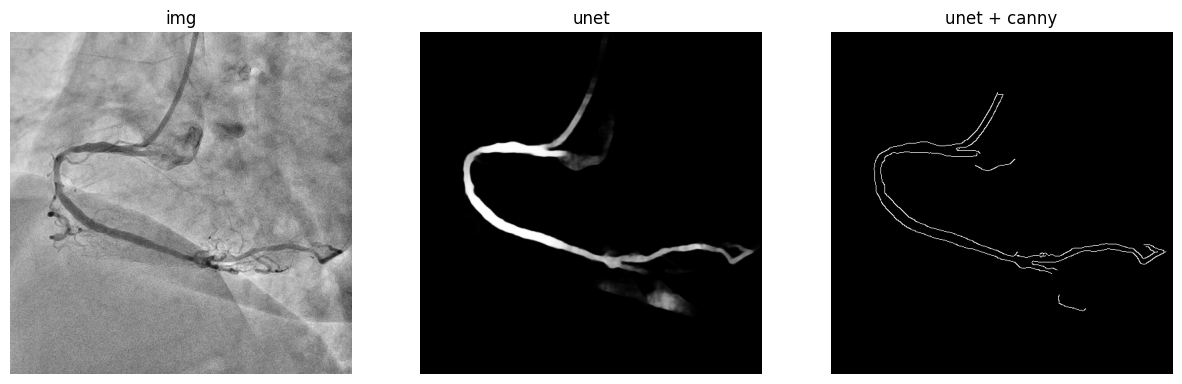

In [8]:
import matplotlib.pyplot as plt

mask = out[0].cpu().detach().permute(1,2,0)
norm = (mask.numpy()*255).astype(np.uint8)
edges = cv2.Canny(norm, 127, 255)

fig, ax = plt.subplots(1, 3, figsize=(15,5))

ax[0].axis('off')
ax[0].set_title('img')
ax[0].imshow(img, cmap='gray')

ax[1].axis('off')
ax[1].set_title('unet')
ax[1].imshow(mask, cmap='gray')

ax[2].axis('off')
ax[2].set_title('unet + canny')
ax[2].imshow(edges, cmap='gray')

In [92]:
np.unique(edges)

array([  0, 255], dtype=uint8)

In [9]:
canny_points = []
for i in range(len(edges)):
    for j in range(len(edges[i])):
        if edges[i,j] != 0:
            canny_points.append([j,i])

canny_points = np.array(canny_points)

In [11]:
img2paint = cv2.cvtColor(img.copy(),cv2.COLOR_GRAY2BGR)

for p in canny_points:
    img2paint = cv2.circle(img2paint,p,0,(0,255,0),1)

cv2.imshow('asd', img2paint)
cv2.waitKey(0)

-1

In [10]:
img2paint = cv2.imread("C:\\Users\\abram\\Downloads\\2025-01-31\\2025-01-31\\86.png", cv2.IMREAD_COLOR)

In [21]:
import numpy as np

file_points = []

def add_points(filepath, points):
    result = points
    f = open(filepath, 'r')
    lines = f.readlines()
    for l in lines:
        i,j = map(float, l.split())
        i = int(i)
        j = int(j)
        result.append([i,j])
    
    return result

r1_86 = "C:\\Users\\abram\\Downloads\\2025-01-31\\2025-01-31\\right1.txt"
l1_86 = "C:\\Users\\abram\\Downloads\\2025-01-31\\2025-01-31\\left1.txt"

r2_84 = "C:\\Users\\abram\\Downloads\\2025-01-31\\2025-01-31\\right2.txt"
l2_84 = "C:\\Users\\abram\\Downloads\\2025-01-31\\2025-01-31\\left2.txt"

file_points = add_points(r1_86, file_points)
file_points = add_points(l1_86, file_points)
X = np.array(file_points)

In [35]:
for p in X:
    img2paint = cv2.circle(img2paint,p,0,(0,255,0),1)

cv2.imshow('asd', img2paint)
cv2.waitKey(0)

-1

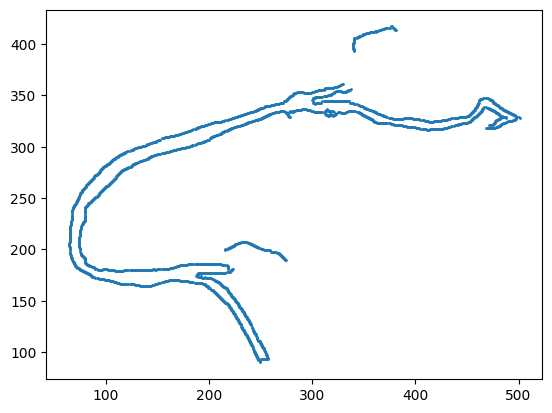

In [70]:
plt.scatter(canny_points[:, 0], canny_points[:, 1],s=1)
plt.show()

In [149]:
s_x = set()
s_y = set()
x = canny_points[:,0]
y = canny_points[:,1]
x_q = []
y_q = []

for i in range(len(x)):
    if y[i] not in s_y and x[i] not in s_x:
        x_q.append(x[i])
        y_q.append(y[i])
        s_y.add(y[i])
        s_x.add(x[i])

len(np.unique(x_q)), len(np.unique(y_q))

(214, 214)

In [147]:
len(x_q), len(y_q)

(214, 214)

In [150]:
from scipy.interpolate import splev, splrep

spl = splrep(x_q, y_q)

spline_x = np.arange(min(x), max(x), 0.5)
spline_y = splev(spline_x, spl)
plt.plot(x_q,y_q, 'o', spline_x, spline_y, '-')
plt.show()

ValueError: Error on input data

In [129]:
y.astype(int).dtype

dtype('int32')

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


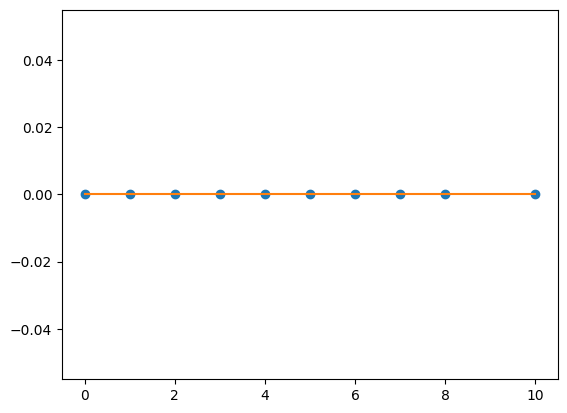

In [127]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import splev, splrep
x = np.linspace(0, 10, 10)
y = np.sin(x)
spl = splrep(x, y)
x2 = np.linspace(0, 10, 200)
y2 = splev(x2, spl)
plt.plot(x, y, 'o', x2, y2)
plt.show()

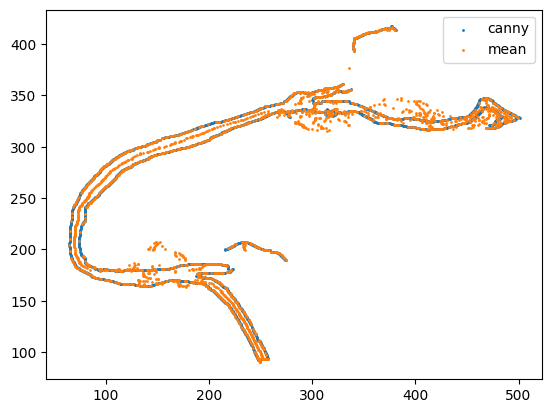

In [96]:
shift = 2
idxs = np.argsort(y)
sorted_x = x[idxs]
sorted_y = y[idxs]
mean_x = []
mean_y = []

for i in range(0, len(sorted_x)-shift):
    mean_x.append(np.mean(sorted_x[i:i+shift]))
    mean_y.append(np.mean(sorted_y[i:i+shift]))

plt.scatter(sorted_x,sorted_y,s=1,label='canny')
plt.scatter(mean_x, mean_y,s=1,label='mean')
plt.legend()
plt.show()

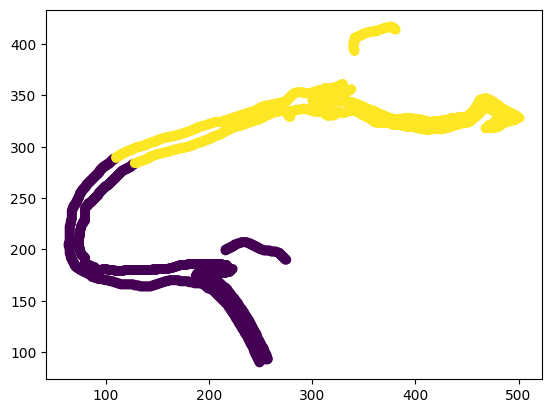

In [174]:
from sklearn.mixture import GaussianMixture

# Применяем GMM
gmm = GaussianMixture(n_components=2)
labels = gmm.fit_predict(canny_points)

# Визуализация
plt.scatter(canny_points[:, 0], canny_points[:, 1], c=labels, cmap='viridis')
plt.show()

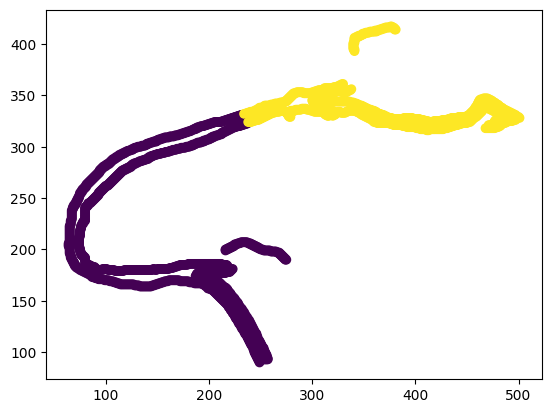

In [175]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

# Применяем k-means с 2 кластерами
kmeans = KMeans(n_clusters=2)
kmeans.fit(canny_points)
labels = kmeans.labels_

# Визуализация
plt.scatter(canny_points[:, 0], canny_points[:, 1], c=labels, cmap='viridis')
plt.show()

c:\soft\miniconda\envs\VCD\lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


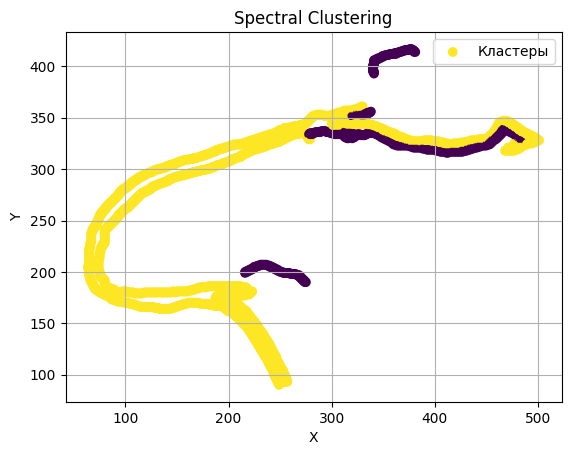

In [186]:
from sklearn.cluster import SpectralClustering

spectral = SpectralClustering(
    n_clusters=2,  # Количество кластеров
    affinity='nearest_neighbors',
    n_neighbors=3,
    random_state=42
)

# Кластеризация
labels = spectral.fit_predict(canny_points)

plt.scatter(canny_points[:, 0], canny_points[:, 1], c=labels, cmap='viridis', label='Кластеры')
plt.title("Spectral Clustering")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()

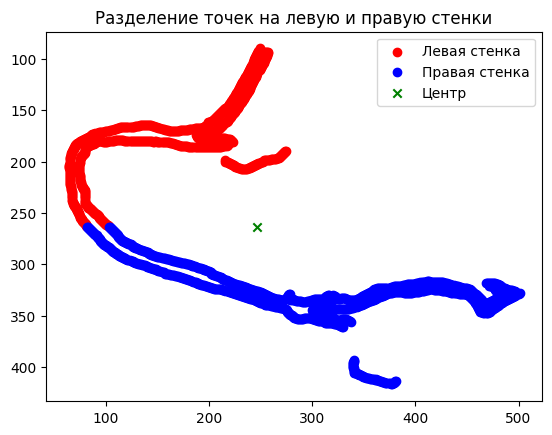

In [193]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import canny
from skimage import filters

# # Пример изображения (замените на ваше изображение)
# image = np.zeros((100, 100))
# image[20:80, 20:80] = 1  # Пример объекта (квадрат)

# # Применяем Canny для выделения границ
# edges = canny(image, sigma=1)

# Находим координаты точек границ
#points = np.column_stack(np.where(edges))

# Находим центр масс точек
center = np.mean(canny_points, axis=0)

# Разделение точек на левую и правую части относительно центра
left_points = canny_points[canny_points[:, 1] < center[1]]
right_points = canny_points[canny_points[:, 1] > center[1]]

# Визуализация
plt.scatter(left_points[:, 0], left_points[:, 1], color='red', label='Левая стенка')
plt.scatter(right_points[:, 0], right_points[:, 1], color='blue', label='Правая стенка')
plt.scatter(center[0], center[1], color='green', marker='x', label='Центр')
plt.legend()
plt.gca().invert_yaxis()
plt.title("Разделение точек на левую и правую стенки")
plt.show()

In [141]:
len(X), len(labels)

(360, 360)

In [142]:
first = []
second = []

for i in range(len(X)):
    if labels[i] == 0:
        first.append(X[i])
    else:
        second.append(X[i])

if first[0][0] < second[0][0]:
    left = first
    right = second
else:
    left = second
    right = first

In [12]:
import os

def save_points(filepath, points):
    os.makedirs(os.path.dirname(filepath), exist_ok=True)

    with open(filepath, 'w') as f:
        for p in points:
            f.write(f'{p[0]} {p[1]}\n')
            
    f.close()

points_86 = 'out/84.txt'
right_path = 'out/right.txt'

save_points(points_86, canny_points)
#save_points(right_path, right)

In [1]:
img2paint = cv2.imread("C:\\Users\\abram\\Downloads\\2025-01-31\\2025-01-31\\86.png", cv2.IMREAD_COLOR)

points_ = []
points = add_points(left_path, points_)
points = add_points(right_path, points_)

for p in points_:
    print(p)
    img2paint = cv2.circle(img2paint,p,0,(0,255,0),1)

cv2.imshow('asd', img2paint)
cv2.waitKey(0)

NameError: name 'cv2' is not defined